# <span style="color:black; font-weight:bold;">Partial alignment breast cancer Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 6.24.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 6.24.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Partial alignment breast cancer data used in the tutorial are available at [XeniumBCARep2.h5ad](https://drive.google.com/file/d/1CeUppdZTBg2NRcKtwUNGqRtgwSiBjUdf/view?usp=sharing) and [XeniumBCARep1.h5ad](https://drive.google.com/file/d/1b5dlnNV6NaMHJ6BfCX4E6LXvXpHeAo-f/view?usp=sharing).
In this tutorial we apply MAPS to align the partially overlapping adjacent slices of breast cancer

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">XeniumBCARep2(ST)</span>: 118,752 cells and 313 genes   
+ <span style="color:black; font-weight:bold;">XeniumBCARep1(ST)</span>: 167,780 spots and 313 genes  

In [1]:
from MAPS.align import partial_alignment,transform_full_source
from MAPS.utils import set_seed,extract_rois,create_new_color_dict
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(2026)

## <span style="color:black; font-weight:bold;">Loading adjacent slices of breast cancer data</span>

In [4]:
source_adata=sc.read_h5ad('/home/dbj/LPcross/Data/BCA_processed/round_1/XeniumBCARep2.h5ad')
source_adata.obs['batch']='XeniumP2'

target_adata=sc.read_h5ad('/home/dbj/LPcross/Data/BCA_processed/round_1/XeniumBCARep1.h5ad')
target_adata.obs['batch']='XeniumP1'

## <span style="color:black; font-weight:bold;">Spatial mapping of the adjacent slices of breast cancer before alignment</span>

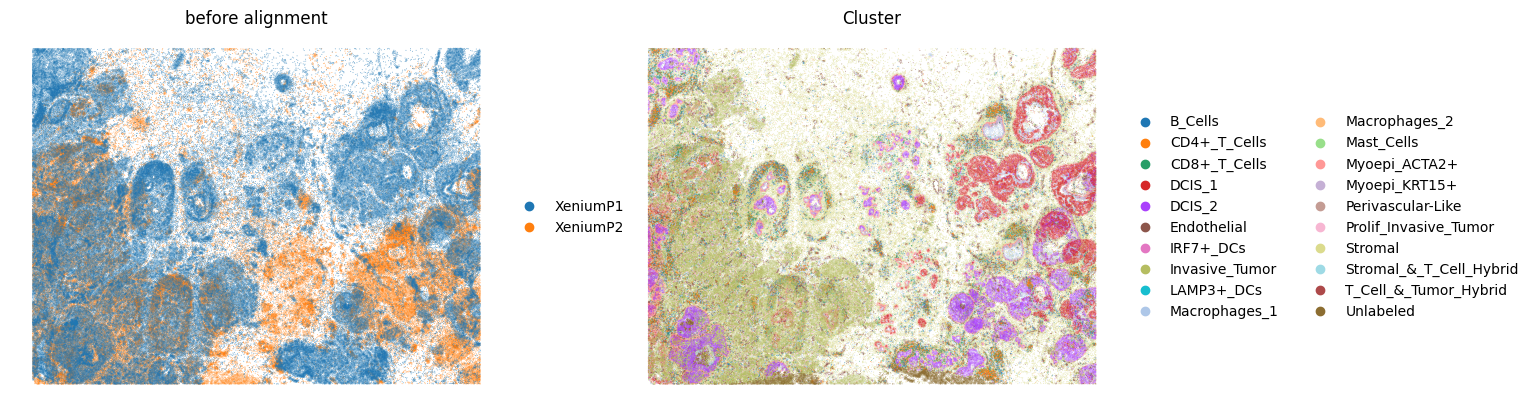

In [5]:
adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','Cluster'],title='before alignment',size=2,alpha=0.6,frameon=False)

## <span style="color:black; font-weight:bold;">Extract the overlapping part of the ROI from the source slice</span>

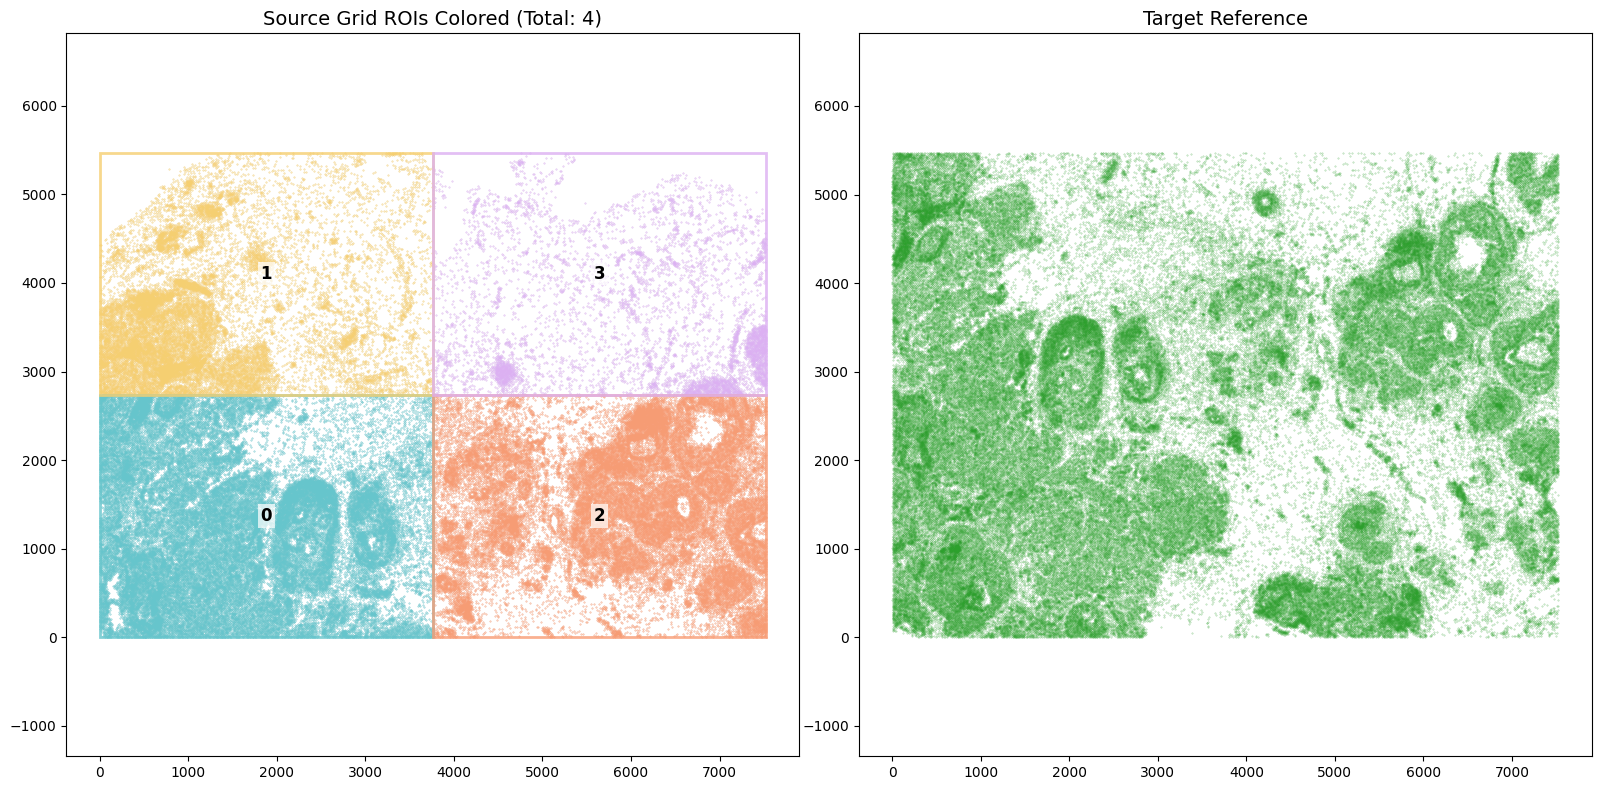

In [6]:
source = source_adata.obsm['spatial'].astype(np.float32) 
target = target_adata.obsm['spatial'].astype(np.float32)

source_roi = extract_rois(source,target,grid_size=(2,2),s=0.1)

## <span style="color:black; font-weight:bold;">Align the overlapping parts and calculate the affine transformation parameters</span>
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ selected_ids: The numbers of overlapping ROI


### <span style="color:black; font-weight:bold;">Output</span>   
+ aligned_roi_np: The coordinates after ROI alignment  
+ theta_deg: Rotation angle  
+ translation_np: Translation matrix

In [7]:
selected_ids = [2]
multi_roi = np.vstack([source_roi[i]['points'] for i in selected_ids])

aligned_roi_np, theta_deg, translation_np = partial_alignment(source=multi_roi,target=target,epochs=2000,sample_size=5000,device=device)

ROI Extracted: 910 valid physical centroids.
Coarse init done! Locked on ROI #857


Align: 100%|███████████████████████████████████████████████████| 2000/2000 [00:04<00:00, 466.81it/s, Loss=42.01, Rot=-358.28°, Trans=(-295.2, 1959.1)]

Rotation angle: 2.19
Translation (x, y): -294.71, 1959.04


## <span style="color:black; font-weight:bold;">Source slice global transformation</span>

In [8]:
final_aligned_source = transform_full_source(source_np=source,roi=multi_roi, theta_deg=theta_deg,translation_np=translation_np)
source_adata.obsm['spatial'] = final_aligned_source

## <span style="color:black; font-weight:bold;">Spatial mapping of the adjacent slices of breast cancer after alignment</span>

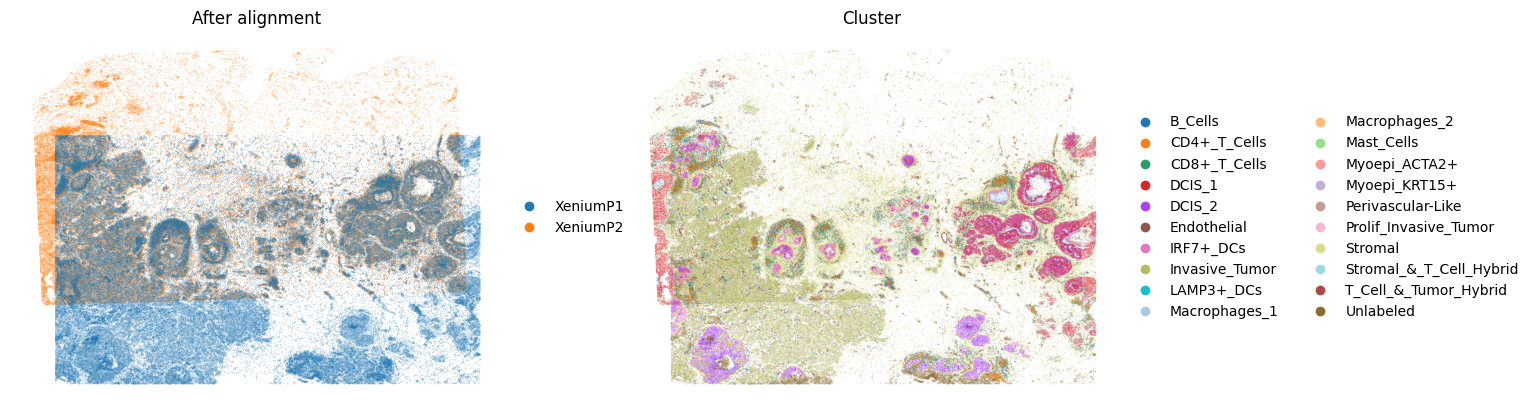

In [9]:
adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color=['batch','Cluster'],title='After alignment',size=1,alpha=0.7,frameon=False)